# Inference Data Analysis
This notebook loads the pickled stats generated by `new_pipeline/inference.py`, slices a specific interval of evaluations (rows), aggregates them, and plots the mean trajectories inline, similar to what `new_pipeline/plot_stats.py` does.

In [1]:
import pickle
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import sys

In [2]:
# Set the path to your inference data log (the pickle file)
stats_file = "/w/150/lambda_squad/misc/clarion_replay/data/inference/melded_notcrewards_hyp4_stats5/inference_results/inference_data_log.pt"

stats_list = []
try:
    with open(stats_file, 'rb') as f:
        while True:
            try:
                stats_list.append(pickle.load(f))
            except EOFError:
                break
    print(f"Loaded {len(stats_list)} stat objects (evaluations) from {stats_file}.")
except FileNotFoundError:
    print(f"Error: file {stats_file} not found. Please update the path.")

Loaded 4538 stat objects (evaluations) from /w/150/lambda_squad/misc/clarion_replay/data/inference/melded_notcrewards_hyp4_stats5/inference_results/inference_data_log.pt.


In [ ]:
def aggregate_sequence_dicts(dict_list):
    if not dict_list:
        return None
    keys = dict_list[0].keys()
    agg = {}
    for k in keys:
        arrays = [d[k] for d in dict_list if k in d and d[k] is not None]
        if not arrays:
            continue
        print("1", arrays.shape)
        max_len = max([a.shape[1] for a in arrays])
        padded_arrays = []
        for a in arrays:
            if a.shape[1] < max_len:
                pad_width = ((0, 0), (0, max_len - a.shape[1]))
                a_padded = np.pad(a, pad_width, mode='constant', constant_values=0)
                padded_arrays.append(a_padded)
            else:
                padded_arrays.append(a)
        agg[k] = np.concatenate(padded_arrays, axis=0)
    print("2", agg.shape)
    return agg

In [5]:
# Select the interval of rows (evaluations) you want to analyze
start_idx = 0
end_idx = 5  # Set to len(stats_list) to use all, or None

if end_idx is None:
    end_idx = len(stats_list)

selected_stats = stats_list[start_idx:end_idx]
print(f"Analyzing evaluations from index {start_idx} to {end_idx - 1} (total: {len(selected_stats)})")

seq_list = [s.get("sequences") for s in selected_stats if s.get("sequences") is not None]
plan_seq_list = [s.get("planner_sequences") for s in selected_stats if s.get("planner_sequences") is not None]

sequences = aggregate_sequence_dicts(seq_list) if seq_list else None
planner_sequences = aggregate_sequence_dicts(plan_seq_list) if plan_seq_list else None

if sequences is not None:
    print(f"Aggregated {len(seq_list)} sequence objects.")
if planner_sequences is not None:
    print(f"Aggregated {len(plan_seq_list)} planner sequence objects.")

Analyzing evaluations from index 0 to 4 (total: 5)
Aggregated 5 sequence objects.
Aggregated 5 planner sequence objects.


In [6]:
def plot_sequences_inline(sequences, title="Sequences across steps"):
    if not sequences:
        print(f"No sequences to plot for {title}.")
        return
        
    plt.figure(figsize=(10, 4))
    colors = plt.cm.tab20.colors + plt.cm.Set3.colors
    
    sequence_names = list(sequences.keys())
    
    for i, sequence in enumerate(sequence_names):
        # Calculate mean across the batch (concatenated) dimension
        mean_seq = sequences[sequence].mean(axis=0)
        color = colors[i % len(colors)]
        plt.plot(
            mean_seq,
            label=sequence,
            color=color
        )
    
    plt.xlabel("Time steps")
    plt.ylabel("Sequence occurrence average")
    plt.title(title)
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()

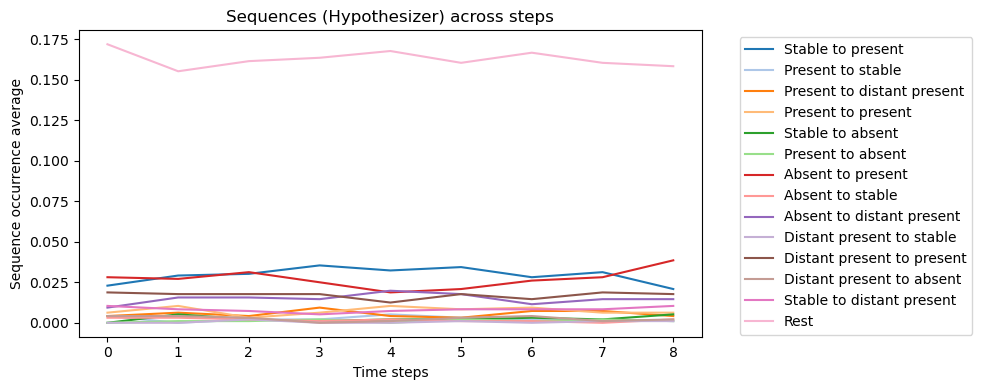

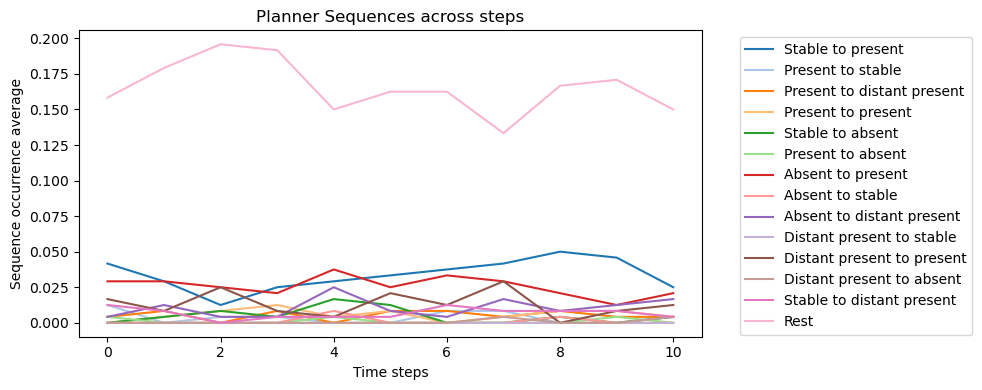

In [7]:
# Plot the results inline
if sequences is not None:
    plot_sequences_inline(sequences, title="Sequences (Hypothesizer) across steps")
    
if planner_sequences is not None:
    plot_sequences_inline(planner_sequences, title="Planner Sequences across steps")